# Phase 1: Baseline Semantic Segmentation on Cityscapes
**Model:** DeepLabV3+ with ResNet34 backbone  
**Dataset:** Cityscapes (19 classes)  
**Goal:** Train a working segmentation baseline to compare against DAFormer and MIC later

## Cell 1: Install Dependencies

In [1]:
!pip install -q -U segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.3 MB/s eta 0:00:00


## Cell 2: Imports

In [2]:
import os
import cv2
cv2.setNumThreads(0)
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import segmentation_models_pytorch as smp
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)

Using device: cuda


## Cell 3: Cityscapes Label Remapping (Raw IDs → 19 Training Classes)

Cityscapes has 34 raw label IDs but only 19 are used for training.
Everything else gets mapped to 255 (ignore index).

In [3]:
# Mapping from raw Cityscapes label ID → training ID (0-18)
# 255 means ignore this class during training
CITYSCAPES_ID_TO_TRAINID = {
    0: 255,   # unlabeled
    1: 255,   # ego vehicle
    2: 255,   # rectification border
    3: 255,   # out of roi
    4: 255,   # static
    5: 255,   # dynamic
    6: 255,   # ground
    7: 0,     # road
    8: 1,     # sidewalk
    9: 255,   # parking
    10: 255,  # rail track
    11: 2,    # building
    12: 3,    # wall
    13: 4,    # fence
    14: 255,  # guard rail
    15: 255,  # bridge
    16: 255,  # tunnel
    17: 5,    # pole
    18: 255,  # polegroup
    19: 6,    # traffic light
    20: 7,    # traffic sign
    21: 8,    # vegetation
    22: 9,    # terrain
    23: 10,   # sky
    24: 11,   # person
    25: 12,   # rider
    26: 13,   # car
    27: 14,   # truck
    28: 15,   # bus
    29: 255,  # caravan
    30: 255,  # trailer
    31: 16,   # train
    32: 17,   # motorcycle
    33: 18,   # bicycle
}

# Class names for visualization
CLASS_NAMES = [
    'road', 'sidewalk', 'building', 'wall', 'fence',
    'pole', 'traffic light', 'traffic sign', 'vegetation', 'terrain',
    'sky', 'person', 'rider', 'car', 'truck',
    'bus', 'train', 'motorcycle', 'bicycle'
]

NUM_CLASSES = 19

# Build fast lookup table (array index = raw label, value = train ID)
label_map = np.full(256, 255, dtype=np.uint8)
for raw_id, train_id in CITYSCAPES_ID_TO_TRAINID.items():
    label_map[raw_id] = train_id

def remap_mask(mask):
    """Convert raw Cityscapes label mask to 19-class training mask."""
    return label_map[mask]

print('Label remapping ready. Training classes:', NUM_CLASSES)

Label remapping ready. Training classes: 19


## Cell 4: Dataset Paths

In [4]:
import glob

# Auto-locate the full-resolution official Cityscapes dataset. Upload the two
# official zips (leftImg8bit_trainvaltest.zip + gtFine_trainvaltest.zip) as
# your own Kaggle dataset and attach it as an input -- this searches for the
# standard 'leftImg8bit' / 'gtFine' folder names anywhere under /kaggle/input,
# so it works regardless of what you name the dataset.

def _find_root(folder_name):
    for root, dirs, _ in os.walk("/kaggle/input"):
        if folder_name in dirs:
            return os.path.join(root, folder_name)
    return None

LEFT_IMG_ROOT = _find_root("leftImg8bit")
GT_ROOT       = _find_root("gtFine")

if LEFT_IMG_ROOT is None or GT_ROOT is None:
    raise FileNotFoundError(
        "Could not find 'leftImg8bit' and/or 'gtFine' folders under /kaggle/input.\n"
        "Upload leftImg8bit_trainvaltest.zip + gtFine_trainvaltest.zip (from "
        "cityscapes-dataset.com) as a Kaggle dataset and attach it to this "
        "notebook as an input."
    )

print("leftImg8bit root:", LEFT_IMG_ROOT)
print("gtFine root:     ", GT_ROOT)

def build_pairs(split):
    """Pair every <city>_<seq>_<frame>_leftImg8bit.png (nested by city) with
    its <city>_<seq>_<frame>_gtFine_labelIds.png mask."""
    img_paths = sorted(glob.glob(
        os.path.join(LEFT_IMG_ROOT, split, "**", "*_leftImg8bit.png"), recursive=True))
    pairs = []
    for img_path in img_paths:
        mask_path = (img_path
                     .replace(LEFT_IMG_ROOT, GT_ROOT)
                     .replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
        if os.path.exists(mask_path):
            pairs.append((img_path, mask_path))
    return pairs

train_pairs = build_pairs("train")
val_pairs   = build_pairs("val")

print(f"Train pairs: {len(train_pairs)}")
print(f"Val pairs:   {len(val_pairs)}")
if not train_pairs or not val_pairs:
    raise RuntimeError("No image/mask pairs found -- check the dataset was uploaded/extracted correctly.")

# Sanity-check native resolution: should now be the real 1024x2048.
_sample = cv2.imread(train_pairs[0][0])
NATIVE_H, NATIVE_W = _sample.shape[:2]
print("Native image resolution (H, W):", (NATIVE_H, NATIVE_W))

leftImg8bit root: /kaggle/input/datasets/khushireddymacha/leftimg/leftImg8bit
gtFine root:      /kaggle/input/datasets/soumikrakshit/cityscapes-coarse-fine/gtFine
Train pairs: 2975
Val pairs:   500
Native image resolution (H, W): (1024, 2048)


## Cell 5: Visualize a Sample (Image + Raw Mask + Remapped Mask)

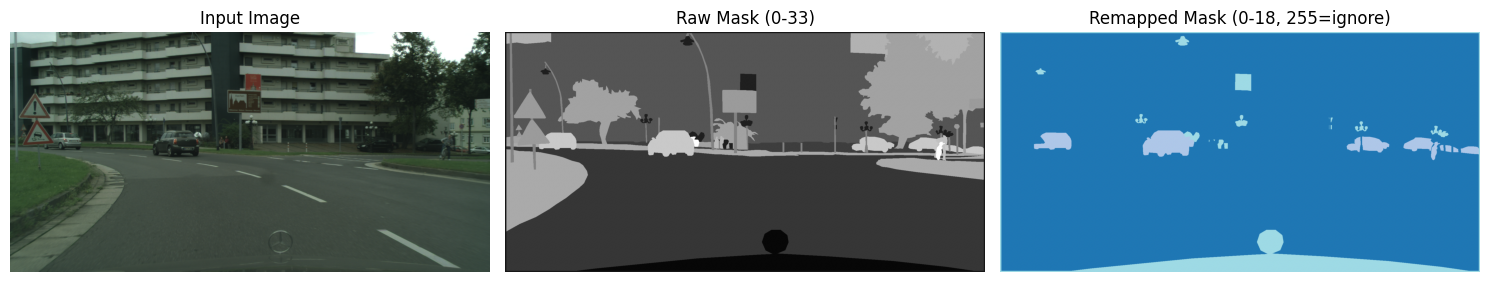

Unique values in remapped mask: [  0   1   2   5   7   8   9  10  11  12  13  18 255]


In [5]:
sample_img_path, sample_mask_path = train_pairs[0]
sample_img  = cv2.cvtColor(cv2.imread(sample_img_path), cv2.COLOR_BGR2RGB)
sample_mask = cv2.imread(sample_mask_path, 0)
sample_remapped = remap_mask(sample_mask)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_img)
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sample_mask, cmap='gray')
plt.title('Raw Mask (0-33)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sample_remapped, cmap='tab20')
plt.title('Remapped Mask (0-18, 255=ignore)')
plt.axis('off')

plt.tight_layout()
plt.show()

print('Unique values in remapped mask:', np.unique(sample_remapped))

## Cell 6: Dataset Class (with augmentation)

Training uses **native-resolution random crops** plus random scale, horizontal flip,
and colour jitter (via `albumentations`) instead of a squished resize — this preserves
thin classes and is the standard Cityscapes recipe. Validation uses an aspect-preserving
resize (512×1024).

In [6]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Full-resolution Cityscapes (~1024x2048) is available now, so train on
# native-resolution random crops (NOT a squished resize) -- this keeps thin
# classes (pole, sign, person, rider, bike) intact and is the standard
# Cityscapes training recipe.
CROP_SIZE    = 512            # random crop size for training
VAL_H, VAL_W = 512, 1024      # validation resize keeps the 2:1 aspect ratio

MEAN = (0.485, 0.456, 0.406)  # ImageNet stats
STD  = (0.229, 0.224, 0.225)

train_aug = A.Compose([
    A.RandomScale(scale_limit=(-0.4, 1.0), p=1.0),
    # Safety net: pads back up to CROP_SIZE if RandomScale (or a smaller than
    # expected image) shrank a side below the crop size.
    A.PadIfNeeded(min_height=CROP_SIZE, min_width=CROP_SIZE,
                  border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=255),
    A.RandomCrop(CROP_SIZE, CROP_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05, p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(VAL_H, VAL_W),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])


class CityscapesDataset(Dataset):

    def __init__(self, pairs, aug):
        self.pairs = pairs   # list of (image_path, mask_path)
        self.aug   = aug

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)
        mask = remap_mask(mask)              # raw IDs -> 19 training classes (255=ignore)

        out = self.aug(image=image, mask=mask)
        return out["image"], out["mask"].long()

print("Dataset + augmentation pipeline defined.")

Dataset + augmentation pipeline defined.


## Cell 7: Create DataLoaders

In [7]:
train_dataset = CityscapesDataset(train_pairs, train_aug)
val_dataset   = CityscapesDataset(val_pairs,   val_aug)

# batch_size=6 is a safe default for mit_b4 (transformer encoder, heavier than a
# CNN) at 512x512 crops on a 16GB GPU (T4/P100). Try 8 if memory allows; drop to
# 4 if you hit OOM.
train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False,
                          num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))

images, masks = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Mask batch shape: ", masks.shape)
print("Unique mask values (0-18 + 255):", torch.unique(masks).tolist())

Train batches: 495
Val batches:   125
Image batch shape: torch.Size([6, 3, 512, 512])
Mask batch shape:  torch.Size([6, 512, 512])
Unique mask values (0-18 + 255): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 255]


## Cell 8: Build Model

**SegFormer / MiT-B4** (ImageNet-pretrained) instead of DeepLabV3+/ResNet — transformer
encoders reach the mid-to-high 70s mIoU on Cityscapes in far fewer epochs than a CNN
backbone, and MiT is also the encoder DAFormer/MIC use in Phase 2, so this baseline stays
architecturally consistent with the rest of the project.

**classes=19** — one output per Cityscapes training class.

In [8]:
model = smp.Segformer(
    encoder_name='mit_b4',
    encoder_weights='imagenet',   # pretrained on ImageNet
    in_channels=3,
    classes=19                    # ✅ correct: 19 Cityscapes classes
).to(DEVICE)

print('Model built: SegFormer / MiT-B4')
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

# mit_b4 is heavier than a ResNet encoder. If you hit CUDA OOM, drop
# batch_size to 4 in the DataLoader cell, or fall back to encoder_name='mit_b3'.

config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

Model built: SegFormer / MiT-B4
Total parameters: 61,373,395


## Cell 9: Loss, Optimizer, and mIoU Function

- **Loss:** OHEM CrossEntropy (mines the hardest pixels each batch — standard for
  transformer segmentation models, speeds up convergence a lot) + Dice (rebalances
  toward small/rare classes).
- **Optimizer:** AdamW (lr=6e-5, the standard SegFormer fine-tuning rate) with linear
  warmup + polynomial decay.
- **mIoU:** correct *global* metric accumulated in a confusion matrix (standard
  Cityscapes evaluation), plus per-class IoU.

In [9]:
from segmentation_models_pytorch.losses import DiceLoss


class OHEMCrossEntropy(nn.Module):
    """
    Online Hard Example Mining CE loss (standard recipe for transformer
    segmentation models, e.g. HRNet/SegFormer training configs). Keeps only
    the hardest pixels per batch instead of averaging over all of them, so
    the model spends more gradient budget on the pixels it's still wrong
    about -> faster mIoU gains per epoch than plain CE.
    """
    def __init__(self, ignore_index=255, thresh=0.7, min_kept=100_000):
        super().__init__()
        self.ignore_index = ignore_index
        self.thresh = thresh
        self.min_kept = max(1, min_kept)
        self.ce = nn.CrossEntropyLoss(ignore_index=ignore_index, reduction="none")

    def forward(self, logits, target):
        pixel_losses = self.ce(logits, target).view(-1)
        valid = target.view(-1) != self.ignore_index

        with torch.no_grad():
            probs = torch.softmax(logits, dim=1)
            safe_target = target.clone()
            safe_target[safe_target == self.ignore_index] = 0
            correct_class_prob = probs.gather(1, safe_target.unsqueeze(1)).view(-1)

        valid_probs = correct_class_prob[valid]
        if valid_probs.numel() == 0:
            return pixel_losses[valid].mean()

        sorted_probs, order = valid_probs.sort()
        keep_idx = min(self.min_kept, sorted_probs.numel() - 1)
        threshold = max(sorted_probs[keep_idx].item(), self.thresh)

        hard_mask = sorted_probs < threshold
        selected = pixel_losses[valid][order][hard_mask]
        if selected.numel() == 0:
            selected = pixel_losses[valid][order][:self.min_kept]
        return selected.mean()


ohem_loss = OHEMCrossEntropy(ignore_index=255, thresh=0.7, min_kept=100_000)
dice_loss = DiceLoss(mode="multiclass", ignore_index=255)

def criterion(logits, target):
    return ohem_loss(logits, target) + dice_loss(logits, target)

EPOCHS = 28   # SegFormer/MiT converges much faster than a CNN backbone
optimizer = torch.optim.AdamW(model.parameters(), lr=6e-5, weight_decay=1e-2)


# ---- Correct global mIoU via a confusion matrix (standard Cityscapes metric) ----
def build_confmat():
    return torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64, device=DEVICE)

@torch.no_grad()
def update_confmat(confmat, preds, labels):
    preds  = preds.flatten()
    labels = labels.flatten()
    valid  = labels != 255
    preds, labels = preds[valid], labels[valid]
    k = labels * NUM_CLASSES + preds
    confmat += torch.bincount(k, minlength=NUM_CLASSES**2).reshape(NUM_CLASSES, NUM_CLASSES)
    return confmat

def iou_from_confmat(confmat):
    inter = torch.diag(confmat).float()
    union = confmat.sum(0).float() + confmat.sum(1).float() - inter
    iou   = inter / union.clamp(min=1)
    present = union > 0                      # ignore classes absent from val set
    return iou.cpu().numpy(), iou[present].mean().item()

print("Loss (OHEM-CE + Dice), AdamW optimizer, and global-mIoU metric ready.")

Loss (OHEM-CE + Dice), AdamW optimizer, and global-mIoU metric ready.


## Cell 10: Training + Validation Loop

In [10]:
CHECKPOINT_PATH = "/kaggle/working/last_checkpoint.pth"

steps_per_epoch = len(train_loader)
warmup_iters    = min(1500, steps_per_epoch)     # linear warmup, then poly decay
total_iters     = EPOCHS * steps_per_epoch

def lr_lambda(step):
    if step < warmup_iters:
        return step / max(1, warmup_iters)
    progress = (step - warmup_iters) / max(1, total_iters - warmup_iters)
    return (1 - progress) ** 0.9

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
scaler    = torch.cuda.amp.GradScaler()

train_losses, val_losses, val_mious = [], [], []
best_miou   = 0.0
start_epoch = 0

# Resume automatically if a checkpoint from an earlier (frozen/interrupted) run
# exists -- if training hangs and you restart the kernel, just re-run this cell
# and it'll pick up where it left off instead of starting over from epoch 0.
if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    scaler.load_state_dict(ckpt["scaler"])
    start_epoch  = ckpt["epoch"] + 1
    best_miou    = ckpt["best_miou"]
    train_losses = ckpt["train_losses"]
    val_losses   = ckpt["val_losses"]
    val_mious    = ckpt["val_mious"]
    print(f"Resumed from checkpoint: starting at epoch {start_epoch+1}/{EPOCHS} "
          f"(best mIoU so far: {best_miou*100:.2f}%)")

for epoch in range(start_epoch, EPOCHS):

    # ── Training ──────────────────────────────────────────
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}] Train")
    for images, masks in loop:
        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss    = criterion(outputs, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()                     # warmup + poly decay, per iteration

        running_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.3f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")
    train_losses.append(running_loss / len(train_loader))

    # ── Validation ────────────────────────────────────────
    model.eval()
    confmat  = build_confmat()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}] Val"):
            images = images.to(DEVICE)
            masks  = masks.to(DEVICE)
            with torch.cuda.amp.autocast():
                outputs = model(images)
                val_loss += criterion(outputs, masks).item()
            update_confmat(confmat, outputs.argmax(1), masks)

    _, val_miou = iou_from_confmat(confmat)
    val_losses.append(val_loss / len(val_loader))
    val_mious.append(val_miou)

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses[-1]:.3f} "
          f"| Val Loss: {val_losses[-1]:.3f} | Val mIoU: {val_miou*100:.2f}%")

    if val_miou > best_miou:
        best_miou = val_miou
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        print(f"  ✅ New best model saved (mIoU: {best_miou*100:.2f}%)")

    # Always save a resumable checkpoint after every epoch (cheap, ~250MB for mit_b4).
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": epoch,
        "best_miou": best_miou,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_mious": val_mious,
    }, CHECKPOINT_PATH)

print(f"\nTraining complete. Best Val mIoU: {best_miou*100:.2f}%")

/tmp/ipykernel_58/108591585.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()
Epoch [1/28] Train:   0%|          | 0/495 [00:00<?, ?it/s]/tmp/ipykernel_58/108591585.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch [1/28] Val:   0%|          | 0/125 [00:00<?, ?it/s]/tmp/ipykernel_58/108591585.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch [1/28] Val: 100%|██████████| 125/125 [00:45<00:00,  2.77it/s]


Epoch 01 | Train Loss: 2.139 | Val Loss: 1.941 | Val mIoU: 41.81%
  ✅ New best model saved (mIoU: 41.81%)


Epoch [2/28] Val: 100%|██████████| 125/125 [00:44<00:00,  2.80it/s]


Epoch 02 | Train Loss: 1.619 | Val Loss: 1.630 | Val mIoU: 55.40%
  ✅ New best model saved (mIoU: 55.40%)


Epoch [3/28] Val: 100%|██████████| 125/125 [00:44<00:00,  2.79it/s]


...

Epoch 26 | Train Loss: 1.274 | Val Loss: 1.375 | Val mIoU: 72.03%


Epoch [27/28] Val: 100%|██████████| 125/125 [00:44<00:00,  2.80it/s]


Epoch 27 | Train Loss: 1.276 | Val Loss: 1.372 | Val mIoU: 72.17%


Epoch [28/28] Val: 100%|██████████| 125/125 [00:44<00:00,  2.79it/s]


Epoch 28 | Train Loss: 1.267 | Val Loss: 1.376 | Val mIoU: 72.19%

Training complete. Best Val mIoU: 72.21%


## Cell 11: Plot Training Curves

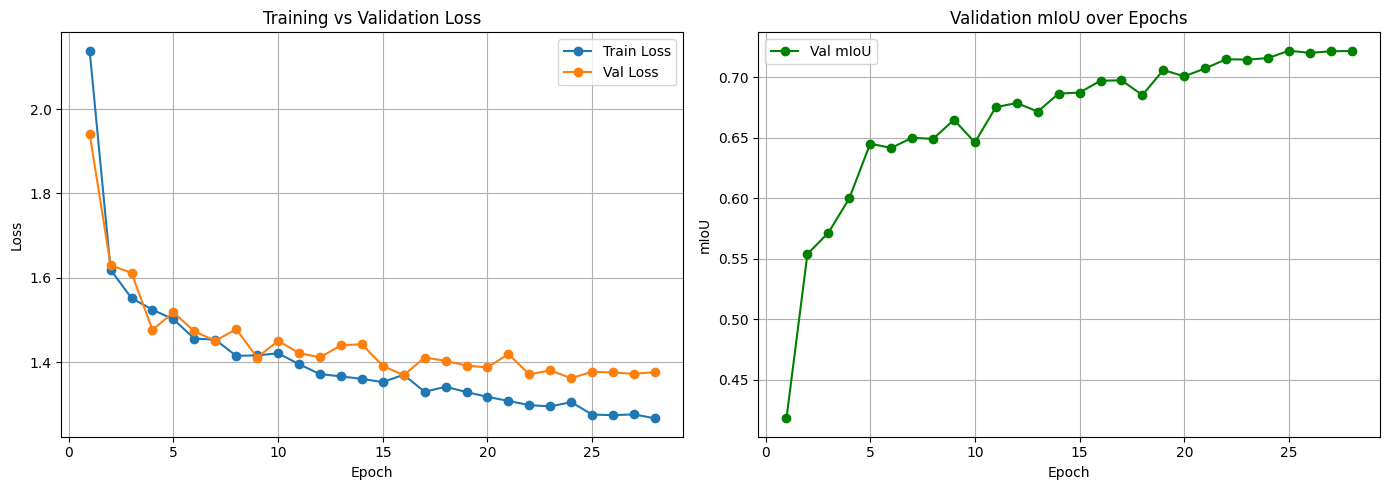

In [14]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, val_losses,   label='Val Loss',   marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_mious, label='Val mIoU', color='green', marker='o')
plt.xlabel('Epoch')
plt.ylabel('mIoU')
plt.title('Validation mIoU over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Cell 12: Load Best Model and Visualize Predictions

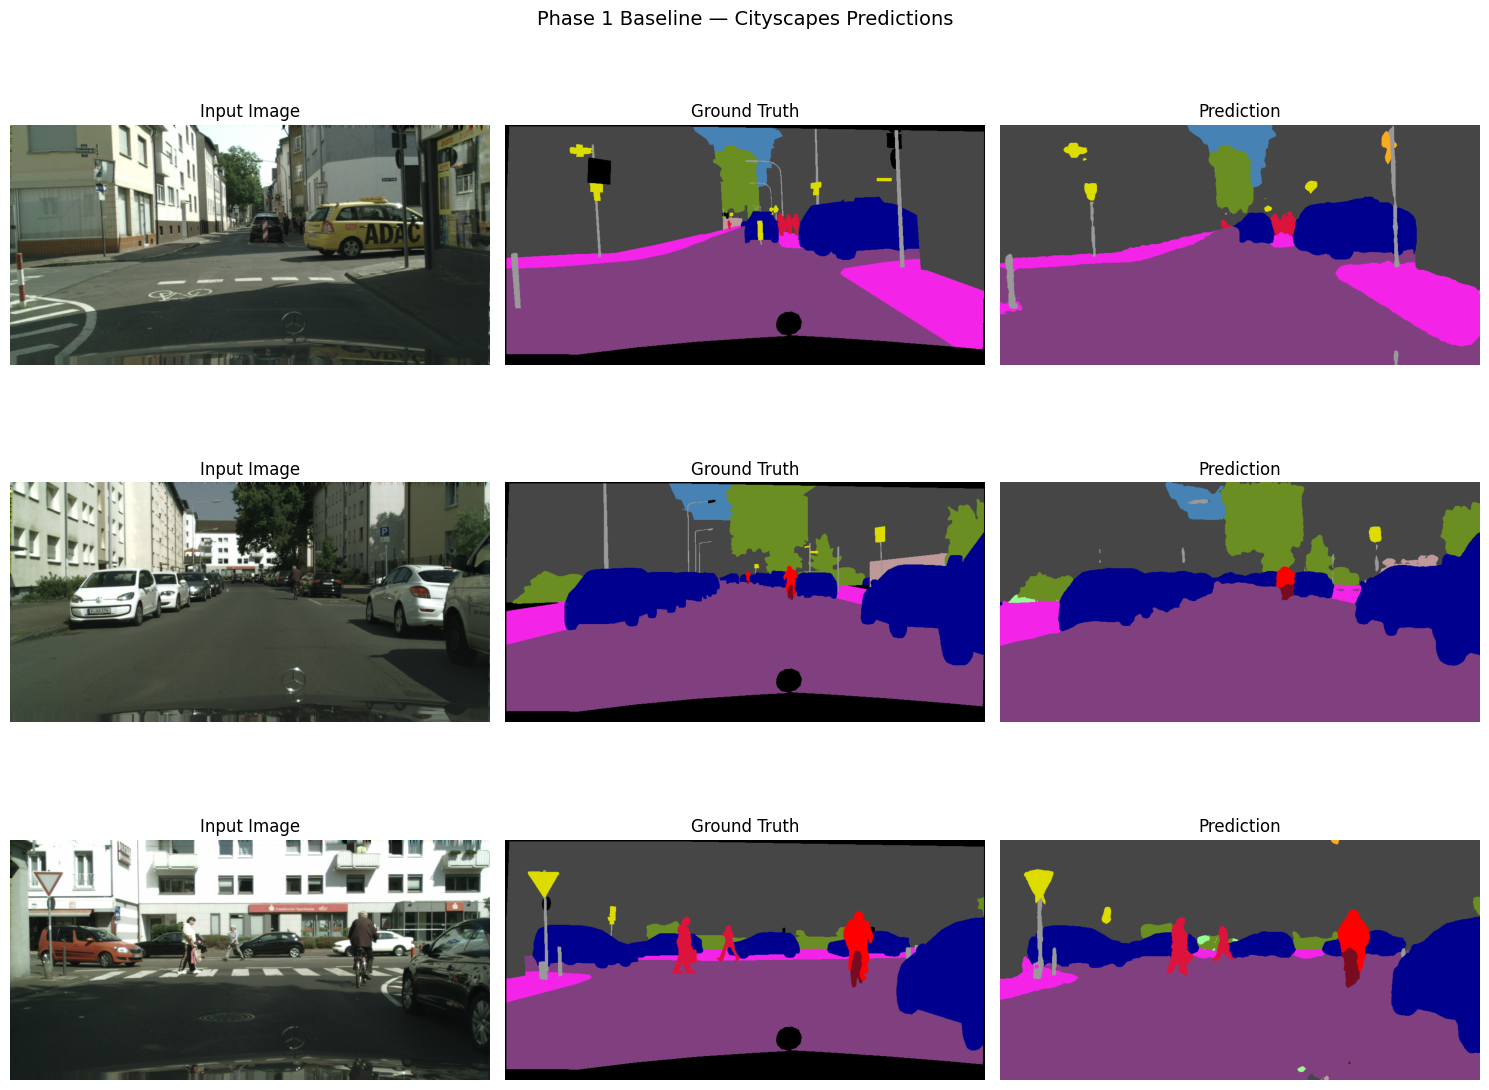

In [15]:
# Load best saved model
model.load_state_dict(torch.load('/kaggle/working/best_model.pth', map_location=DEVICE))
model.eval()

# Color palette for 19 classes
PALETTE = np.array([
    [128, 64, 128],   # road
    [244, 35, 232],   # sidewalk
    [70, 70, 70],     # building
    [102, 102, 156],  # wall
    [190, 153, 153],  # fence
    [153, 153, 153],  # pole
    [250, 170, 30],   # traffic light
    [220, 220, 0],    # traffic sign
    [107, 142, 35],   # vegetation
    [152, 251, 152],  # terrain
    [70, 130, 180],   # sky
    [220, 20, 60],    # person
    [255, 0, 0],      # rider
    [0, 0, 142],      # car
    [0, 0, 70],       # truck
    [0, 60, 100],     # bus
    [0, 80, 100],     # train
    [0, 0, 230],      # motorcycle
    [119, 11, 32],    # bicycle
], dtype=np.uint8)

def mask_to_color(mask):
    """Convert class index mask to RGB color image."""
    color_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for cls in range(19):
        color_mask[mask == cls] = PALETTE[cls]
    return color_mask

# Visualize 3 validation samples
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i in range(3):
    image, mask = val_dataset[i]
    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(DEVICE))
        pred_mask = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

    # Denormalize image for display
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_display = image.permute(1, 2, 0).numpy()
    img_display = (img_display * std + mean).clip(0, 1)

    gt_color   = mask_to_color(mask.numpy())
    pred_color = mask_to_color(pred_mask)

    axes[i][0].imshow(img_display)
    axes[i][0].set_title('Input Image')
    axes[i][0].axis('off')

    axes[i][1].imshow(gt_color)
    axes[i][1].set_title('Ground Truth')
    axes[i][1].axis('off')

    axes[i][2].imshow(pred_color)
    axes[i][2].set_title('Prediction')
    axes[i][2].axis('off')

plt.suptitle('Phase 1 Baseline — Cityscapes Predictions', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 13: Final mIoU on Full Validation Set (with multi-scale + flip TTA)

Test-time augmentation (scales 0.75/1.0/1.25, each with a horizontal flip, probabilities
averaged) typically adds another +1-2% mIoU for free at eval time.

In [16]:
model.load_state_dict(torch.load("/kaggle/working/best_model.pth", map_location=DEVICE))
model.eval()

TTA_SCALES = [0.75, 1.0, 1.25]

@torch.no_grad()
def tta_predict(model, images):
    B, C, H, W = images.shape
    probs = torch.zeros(B, NUM_CLASSES, H, W, device=DEVICE)
    for scale in TTA_SCALES:
        h, w = int(H * scale), int(W * scale)
        scaled = nn.functional.interpolate(images, size=(h, w), mode="bilinear", align_corners=False)
        for flip in (False, True):
            inp = torch.flip(scaled, dims=[3]) if flip else scaled
            with torch.cuda.amp.autocast():
                out = model(inp)
            out = nn.functional.interpolate(out.float(), size=(H, W), mode="bilinear", align_corners=False)
            if flip:
                out = torch.flip(out, dims=[3])
            probs += torch.softmax(out, dim=1)
    return probs

confmat = build_confmat()
with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="Computing final mIoU (TTA)"):
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)
        probs  = tta_predict(model, images)
        update_confmat(confmat, probs.argmax(1), masks)

per_class_iou, final_miou = iou_from_confmat(confmat)

print("\nPer-class IoU:")
for name, v in zip(CLASS_NAMES, per_class_iou):
    print(f"  {name:15s}: {v*100:5.2f}%")

print("\n=============================")
print(f"Phase 1 Baseline mIoU: {final_miou*100:.2f}%")
print("=============================")
print("This is your reference score. DAFormer and MIC should improve on this.")

Computing final mIoU (TTA):   0%|          | 0/125 [00:00<?, ?it/s]/tmp/ipykernel_58/354798084.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Computing final mIoU (TTA): 100%|██████████| 125/125 [04:08<00:00,  1.99s/it]


Per-class IoU:
  road           : 97.35%
  sidewalk       : 79.33%
  building       : 90.41%
  wall           : 58.27%
  fence          : 53.90%
  pole           : 47.73%
  traffic light  : 58.81%
  traffic sign   : 68.90%
  vegetation     : 90.56%
  terrain        : 60.63%
  sky            : 93.30%
  person         : 73.96%
  rider          : 54.48%
  car            : 92.58%
  truck          : 82.88%
  bus            : 81.82%
  train          : 75.85%
  motorcycle     : 59.64%
  bicycle        : 70.03%

Phase 1 Baseline mIoU: 73.18%
This is your reference score. DAFormer and MIC should improve on this.
